# Feature Engineering 

**Objective:** build account-level features from transactional behavior, applying the decisions established in the EDA notebook (Section 7.5), and produce train/test datasets ready for modeling.

**Task addressed:** build account-level features from the transactional data, based on the structure of the transactions and the goal of identifying suspicious accounts.

**Contents:**
1. Setup and data loading
2. Data leakage prevention strategy (pipeline ordering)
3. Stratified train/test split
4. `TX_AMOUNT` treatment (winsorization)
5. Feature construction
6. Feature quality verification
7. Preliminary signal analysis
8. Dataset export

**Decisions inherited from the EDA:**

| Decision | Source |
|---|---|
| Target: `accounts.IS_FRAUD`, without redefinition | EDA 3.7 |
| Drop `COUNTRY`, `ACCOUNT_TYPE` (zero variance) and `CUSTOMER_ID` (redundant) | EDA 3.6, 2.1.1 |
| Winsorize `TX_AMOUNT` (p99) due to the integer overflow defect | EDA 3.5.1 |
| Winsorization threshold computed on the training set only | EDA 7.5 |
| Exclude `ALERT_ID` and transaction-level `IS_FRAUD` (direct leakage) | EDA 7.5 |
| Prioritize structural network features over raw counts | EDA 5.3, 5.4 |

## 1. Setup and data loading

In [12]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
TEST_SIZE = 0.25

DATA_DIR = "./"
accounts = pd.read_csv(DATA_DIR + "accounts.csv")
transactions = pd.read_csv(DATA_DIR + "transactions.csv")

print("accounts:", accounts.shape)
print("transactions:", transactions.shape)

accounts: (10000, 7)
transactions: (1323234, 8)


## 2. Data leakage prevention strategy

Avoiding data leakage is a core requirement of this problem. Two independent leakage channels exist in this problem and must be closed separately.

### 2.1 Leakage through target-derived columns

`transactions.csv` contains two columns that reveal the answer directly:

- **Transaction-level `IS_FRAUD`** — the label itself, propagated to the transaction.
- **`ALERT_ID`** — any value other than `-1` indicates the transaction belongs to a confirmed laundering pattern.

A model using either would achieve near-perfect performance without learning anything about behavior. **Both are excluded entirely** from feature construction. Only `SENDER_ACCOUNT_ID`, `RECEIVER_ACCOUNT_ID`, `TX_AMOUNT` and `TIMESTAMP` are used.

### 2.2 Leakage through statistics computed on the full dataset

The EDA (Section 3.5.1) established that `TX_AMOUNT` must be winsorized at the 99th percentile due to the integer overflow defect. Computing that percentile over the full dataset would embed statistical information from the test set into the threshold — a subtle but real form of leakage.

The threshold is not a universal constant; it is a **parameter learned from data**, exactly like a model coefficient. A threshold calibrated with knowledge of the test set produces an optimistic evaluation that cannot be reproduced in production, where no such forward-looking information exists.

**Implication for pipeline ordering:** features are aggregations over transactions, but the winsorization threshold depends on the partition. The train/test split must therefore occur **before** feature engineering, not after.

**Adopted ordering:**

1. Split **accounts** into train/test (stratified by `IS_FRAUD`).
2. Compute the 99th percentile of `TX_AMOUNT` using **exclusively** transactions whose sender belongs to the training set.
3. Apply that fixed threshold to **all** transactions (train and test).
4. Build features for all accounts.

**Note on the subset used to compute the threshold:** each transaction connects two accounts, which may belong to different partitions (sender in train, receiver in test). The **sender's** partition is adopted as the convention for delimiting which transactions feed the percentile calculation. The choice is arbitrary — using the receiver would have been equally valid — and its effect is marginal given that the output is a single scalar. It is declared explicitly for traceability.

This convention applies **exclusively** to the threshold calculation. Feature construction uses the complete transactional history of every account, without any filter.

**On scaling:** the `StandardScaler` required by logistic regression must likewise be fitted on training data only. That step is executed in the modeling notebook within a scikit-learn `Pipeline`, ensuring the fit occurs only on training folds during cross-validation.

## 3. Stratified train/test split

**Stratification:** with only 16.85% positive accounts, simple random sampling could yield partitions with divergent class proportions, biasing the evaluation. Stratification preserves the original proportion in both sets.

**Unit of division:** the split is performed over **accounts**, not transactions, because the unit of prediction is the account. Transactions are never partitioned — each account's features are built from its complete transactional history regardless of which partition its counterparties fall into.

**On the absence of a temporal split:** the target is static at the account level and the dataset does not pose a forward-prediction scenario, so a stratified random split is appropriate. In a real deployment a temporal split (training on earlier periods, evaluating on later ones) would better reflect production conditions; this is documented as a recommendation for next steps.

In [13]:
train_ids, test_ids = train_test_split(
    accounts["ACCOUNT_ID"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=accounts["IS_FRAUD"],
)

train_ids = set(train_ids)
test_ids = set(test_ids)

split_summary = pd.DataFrame({
    "n_accounts": [len(train_ids), len(test_ids)],
    "n_fraud": [
        accounts[accounts["ACCOUNT_ID"].isin(train_ids)]["IS_FRAUD"].sum(),
        accounts[accounts["ACCOUNT_ID"].isin(test_ids)]["IS_FRAUD"].sum(),
    ],
}, index=["train", "test"])
split_summary["pct_fraud"] = (split_summary["n_fraud"] / split_summary["n_accounts"] * 100).round(2)

print(split_summary)
print(f"\nOriginal fraud proportion: {accounts['IS_FRAUD'].mean()*100:.2f}%")

       n_accounts  n_fraud  pct_fraud
train        7500     1264      16.85
test         2500      421      16.84

Original fraud proportion: 16.85%


## 4. `TX_AMOUNT` treatment — winsorization

The EDA documented a 32-bit integer overflow in `TX_AMOUNT`: 3,053 transactions pinned exactly at \$21,474,836.47, with 73.4% of accounts touching at least one transaction above \$1,000,000 — an implausible magnitude against a maximum initial balance of \$599.60.

**Strategy:** winsorization (capping the upper tail at the 99th percentile) rather than censoring as missing data. With 73.4% of accounts affected, treating those values as missing would incur a disproportionate loss of information.

**Signal preservation:** capping removes the distorted magnitude, but the fact that an account participated in extreme transactions is potentially informative. This is preserved through separate counters (`n_extreme_sent`, `n_extreme_recv`), decoupling the occurrence from the amount.

In [14]:
# The threshold is computed EXCLUSIVELY from transactions whose sender belongs to train
tx_train_scope = transactions[transactions["SENDER_ACCOUNT_ID"].isin(train_ids)]
AMOUNT_CAP = tx_train_scope["TX_AMOUNT"].quantile(0.99)

print(f"Winsorization threshold (p99, train only): ${AMOUNT_CAP:,.2f}")
print(f"Transactions above the threshold (full dataset): "
      f"{(transactions['TX_AMOUNT'] > AMOUNT_CAP).sum():,} "
      f"({(transactions['TX_AMOUNT'] > AMOUNT_CAP).mean()*100:.2f}%)")

# The fixed threshold is applied to ALL transactions
transactions["TX_AMOUNT_CAPPED"] = transactions["TX_AMOUNT"].clip(upper=AMOUNT_CAP)
transactions["IS_EXTREME"] = (transactions["TX_AMOUNT"] > AMOUNT_CAP).astype(int)

print("\nEffect on the distribution:")
comparison = pd.DataFrame({
    "original": transactions["TX_AMOUNT"].agg(["mean", "median", "std", "max"]),
    "winsorized": transactions["TX_AMOUNT_CAPPED"].agg(["mean", "median", "std", "max"]),
})
print(comparison.round(2))

Winsorization threshold (p99, train only): $1,826,133.46
Transactions above the threshold (full dataset): 13,308 (1.01%)

Effect on the distribution:
           original  winsorized
mean      115988.18    24517.35
median       156.71      156.71
std      1320090.68   196026.74
max     21474836.47  1826133.46


**Reading the result:** the median is unchanged — winsorization does not touch the centre of the distribution — while the mean and standard deviation fall substantially. This is the intended behavior: the scale distortion documented in the EDA is neutralized without altering typical account behavior. Had the median shifted, it would indicate the threshold was aggressive enough to be clipping legitimate activity rather than the defect alone.

## 5. Feature construction

The design principle is that the model can only see what it is given, and the typologies present (`fan_in` and `cycle`) are patterns of **structure**, not of volume. The feature set therefore prioritizes *with whom* and *how* an account transacts, not merely *how much*.

Features are organized into seven families:

| Family | What it captures | AML relevance |
|---|---|---|
| **Volume** | How many transactions and at what amount | Baseline activity; normalization context |
| **Network degree** | How many *distinct* counterparties | `fan_in` = abnormally high in-degree |
| **Flow** | Balance between inbound and outbound | Pass-through accounts: receive and drain |
| **Counterparty repetition** | Transactions per distinct counterparty | Low value with high in-degree = structuring |
| **Reciprocity** | Counterparties both sent to and received from | Direct signature of a `cycle` |
| **Temporal** | Concentration of activity over time | Schemes execute in bursts |
| **Balance-relative** | Movement relative to initial balance | Turnover disproportionate to the account profile |

### 5.1 Outbound flow aggregations (sender side)

**Volume features** (`n_tx_sent`, `amt_sent_total`, `amt_sent_mean`, `amt_sent_median`, `amt_sent_std`, `amt_sent_max`) establish the baseline against which structural features are interpreted. An in-degree of 300 means something different for an account with 10 transactions than for one with 10,000; without volume, structural features have nothing to normalize against.

**Mean *and* median are both retained** because their divergence is itself informative: an account whose mean substantially exceeds its median has atypical transactions concentrated in its tail — information neither statistic conveys alone.

**Network degree** (`out_degree_unique`) counts *distinct* receiving counterparties rather than transactions. This distinction is central to the feature design and is developed in Section 5.2.

**Extreme-value counter** (`n_extreme_sent`) preserves the occurrence signal removed by winsorization.

**Temporal features** (`first_ts_sent`, `last_ts_sent`, `n_active_ts_sent`) capture the account's activity window and the density of that activity.

In [15]:
out_features = transactions.groupby("SENDER_ACCOUNT_ID").agg(
    # Volume
    n_tx_sent=("TX_ID", "count"),
    amt_sent_total=("TX_AMOUNT_CAPPED", "sum"),
    amt_sent_mean=("TX_AMOUNT_CAPPED", "mean"),
    amt_sent_median=("TX_AMOUNT_CAPPED", "median"),
    amt_sent_std=("TX_AMOUNT_CAPPED", "std"),
    amt_sent_max=("TX_AMOUNT_CAPPED", "max"),
    # Network degree
    out_degree_unique=("RECEIVER_ACCOUNT_ID", "nunique"),
    # Extreme values (signal preserved post-winsorization)
    n_extreme_sent=("IS_EXTREME", "sum"),
    # Temporal
    first_ts_sent=("TIMESTAMP", "min"),
    last_ts_sent=("TIMESTAMP", "max"),
    n_active_ts_sent=("TIMESTAMP", "nunique"),
).rename_axis("ACCOUNT_ID")

print("Outbound flow features:", out_features.shape)
out_features.head()

Outbound flow features: (9999, 11)


,n_tx_sent,amt_sent_total,amt_sent_mean,amt_sent_median,amt_sent_std,amt_sent_max,out_degree_unique,n_extreme_sent,first_ts_sent,last_ts_sent,n_active_ts_sent
ACCOUNT_ID,,,,,,,,,,,
1,24,4219.20,175.80,175.80,0.0,175.80,1,0,6,199,24
2,18,2556.90,142.05,142.05,0.0,142.05,1,0,34,197,18
3,19,2391.72,125.88,125.88,0.0,125.88,1,0,27,197,19
4,23,3475.99,151.13,151.13,0.0,151.13,1,0,11,194,23
5,38,2669.12,70.24,70.24,0.0,70.24,2,0,5,189,19


### 5.2 Inbound flow aggregations (receiver side)

Mirrors Section 5.1 on the receiving side. **This is where the strongest signal is expected**, since `fan_in` concentrates its anomaly on the receiving account while the sending accounts in the scheme behave close to normally.

**The critical distinction — transactions vs. distinct counterparties.** The EDA (Section 5.3) showed that raw transaction counts separate the classes only weakly. The reason is that receiving 50 transactions from the *same* account is not equivalent to receiving 50 transactions from 50 *different* accounts:

| | `n_tx_recv` | `in_degree_unique` |
|---|---|---|
| Account A: 50 transactions, all from one counterparty | 50 | **1** |
| Account B: 50 transactions, from 50 distinct counterparties | 50 | **50** |

Raw counts treat these as identical. Account B is a textbook `fan_in` (many senders converging); Account A resembles an ordinary commercial relationship. `in_degree_unique` distinguishes them; `n_tx_recv` cannot. Both are constructed so the model can exploit the difference.

In [16]:
in_features = transactions.groupby("RECEIVER_ACCOUNT_ID").agg(
    n_tx_recv=("TX_ID", "count"),
    amt_recv_total=("TX_AMOUNT_CAPPED", "sum"),
    amt_recv_mean=("TX_AMOUNT_CAPPED", "mean"),
    amt_recv_median=("TX_AMOUNT_CAPPED", "median"),
    amt_recv_std=("TX_AMOUNT_CAPPED", "std"),
    amt_recv_max=("TX_AMOUNT_CAPPED", "max"),
    in_degree_unique=("SENDER_ACCOUNT_ID", "nunique"),
    n_extreme_recv=("IS_EXTREME", "sum"),
    first_ts_recv=("TIMESTAMP", "min"),
    last_ts_recv=("TIMESTAMP", "max"),
    n_active_ts_recv=("TIMESTAMP", "nunique"),
).rename_axis("ACCOUNT_ID")

print("Inbound flow features:", in_features.shape)
in_features.head()

Inbound flow features: (9926, 11)


,n_tx_recv,amt_recv_total,amt_recv_mean,amt_recv_median,amt_recv_std,amt_recv_max,in_degree_unique,n_extreme_recv,first_ts_recv,last_ts_recv,n_active_ts_recv
ACCOUNT_ID,,,,,,,,,,,
3,23,3.134900e+02,13.630000,13.63,0.000000,1.363000e+01,1,0,27,184,23
5,19,1.567500e+02,8.250000,8.25,0.000000,8.250000e+00,1,0,2,192,19
6,20,3.823800e+03,191.190000,191.19,0.000000,1.911900e+02,1,0,1,191,20
7,20,2.816600e+03,140.830000,140.83,0.000000,1.408300e+02,1,0,8,198,20
9,3,2.712041e+06,904013.633467,878895.81,909820.991872,1.826133e+06,1,1,21,149,3


### 5.3 Reciprocity — circularity detection

**Rationale:** a `cycle` implies that funds traverse a chain of accounts and return to the origin. At the level of an individual account, the observable signature is the existence of **bidirectional counterparties**: accounts to which the node sends money *and* from which it also receives.

In legitimate commercial flow this is uncommon — a supplier collects payment and does not return it. In a layering scheme it is structural: funds circulate in both directions by design.

**Calculation:** unique directed pairs (sender → receiver) are extracted from the transaction graph, and the intersection of both directions is counted per account.

In [17]:
# Unique directed edges of the transaction graph
edges = transactions[["SENDER_ACCOUNT_ID", "RECEIVER_ACCOUNT_ID"]].drop_duplicates()

# "Sends to" perspective: account -> counterparty
sent_to = edges.rename(columns={"SENDER_ACCOUNT_ID": "ACC", "RECEIVER_ACCOUNT_ID": "CP"})
# "Receives from" perspective: account <- counterparty
recv_from = edges.rename(columns={"SENDER_ACCOUNT_ID": "CP", "RECEIVER_ACCOUNT_ID": "ACC"})

# Intersection: counterparties present in both directions
reciprocal = pd.merge(sent_to, recv_from, on=["ACC", "CP"])
reciprocal_counts = (
    reciprocal.groupby("ACC").size().rename("n_reciprocal_cp").rename_axis("ACCOUNT_ID")
)

print(f"Accounts with at least one bidirectional counterparty: {len(reciprocal_counts):,} of {len(accounts):,}")
print(f"Maximum bidirectional counterparties for a single account: {reciprocal_counts.max()}")

Accounts with at least one bidirectional counterparty: 2,438 of 10,000
Maximum bidirectional counterparties for a single account: 7


### 5.4 Assembly and derived features

**Accounts without activity:** the EDA identified 1 account that never sends and 74 that never receive. After the join, their aggregations are `NaN`; these are imputed with **0**, which is the semantically correct value (zero transactions, zero amount) rather than a missing value.

**Denominators:** all ratios use `+1` in the denominator to prevent division by zero for accounts with no activity in one direction.

---

#### Rationale for each derived feature

**Flow family — why ratios and not only differences.** An account receiving \$1M and sending \$1M has `amt_net_flow = 0`, as does one receiving \$10 and sending \$10. The **ratio** distinguishes both from an account receiving \$1M and sending nothing. Ratios are scale-invariant; differences are not. Both are retained.

| Feature | Definition | Behavior detected |
|---|---|---|
| `amt_net_flow` | received − sent | Whether the account accumulates or drains |
| `ratio_amt_in_out` | received / sent | ≈1 → pass-through account: receives and empties |
| `ratio_cnt_in_out` | tx received / tx sent | Directional imbalance in frequency |
| `ratio_degree_in_out` | inbound / outbound counterparties | High → convergence (`fan_in`) |

**Counterparty repetition family.** Complements network degree by measuring *how much* activity concentrates on the same counterparty.

| Feature | Interpretation |
|---|---|
| `tx_per_cp_sent` / `tx_per_cp_recv` | **High** → intense relationship with few accounts (regular supplier, payroll). **Low** combined with high in-degree → many distinct senders each contributing little: the signature of **structuring/smurfing** |

**Reciprocity family — why the ratio in addition to the count.** An account with 5 bidirectional counterparties out of 500 total (1%) is materially different from one with 5 out of 8 (62%). The raw count cannot distinguish them; `reciprocity_ratio` can.

**Temporal family — burstiness.** Laundering schemes do not execute evenly over time; they execute quickly, in bursts, to minimize exposure. An account with 100 transactions spread across 100 timesteps behaves differently from one with 100 transactions across 5 timesteps, even though both have identical volume. `burstiness_*` divides transactions by active timesteps to capture exactly this.

**Balance-relative family — `turnover_ratio`.** The most domain-specific feature in the set. In real AML compliance, the classic signal is not *how much money an account moves* but **how much it moves relative to what its profile would justify**. An account with a \$150 initial balance moving \$50,000 is materially more suspicious than one moving the same amount against a \$500,000 balance. `turnover_ratio` operationalizes this.

**Extreme-value family — `n_extreme_*`.** Preserves the occurrence of overflow-affected transactions, decoupled from their corrupted magnitude. **Interpretive caution is required:** the EDA (3.5.1) established that extreme transactions are distributed almost uniformly across classes (18.60% fraud rate among affected accounts vs. a 16.85% baseline). Any correlation these features exhibit with the target is therefore likely **mechanical** — accounts with more inbound transactions are more likely to touch at least one extreme value purely by volume, not because their behavior is anomalous. Their contribution will be assessed with SHAP in the modeling notebook; if confirmed as non-behavioral, exclusion will be evaluated.

In [18]:
features = (
    accounts.set_index("ACCOUNT_ID")[["INIT_BALANCE", "TX_BEHAVIOR_ID", "IS_FRAUD"]]
    .join([out_features, in_features, reciprocal_counts], how="left")
    .fillna(0)
)

# --- Combined volume
features["n_tx_total"] = features["n_tx_sent"] + features["n_tx_recv"]
features["amt_total_moved"] = features["amt_sent_total"] + features["amt_recv_total"]

# --- Flow: inbound/outbound balance
features["amt_net_flow"] = features["amt_recv_total"] - features["amt_sent_total"]
features["ratio_amt_in_out"] = features["amt_recv_total"] / (features["amt_sent_total"] + 1)
features["ratio_cnt_in_out"] = features["n_tx_recv"] / (features["n_tx_sent"] + 1)
features["ratio_degree_in_out"] = features["in_degree_unique"] / (features["out_degree_unique"] + 1)

# --- Counterparty repetition
features["tx_per_cp_sent"] = features["n_tx_sent"] / (features["out_degree_unique"] + 1)
features["tx_per_cp_recv"] = features["n_tx_recv"] / (features["in_degree_unique"] + 1)

# --- Normalized reciprocity
features["reciprocity_ratio"] = features["n_reciprocal_cp"] / (
    features["out_degree_unique"] + features["in_degree_unique"] + 1
)

# --- Balance-relative
features["turnover_ratio"] = features["amt_sent_total"] / (features["INIT_BALANCE"] + 1)

# --- Extreme values
features["n_extreme_tx"] = features["n_extreme_sent"] + features["n_extreme_recv"]

# --- Temporal
features["active_span_sent"] = features["last_ts_sent"] - features["first_ts_sent"]
features["active_span_recv"] = features["last_ts_recv"] - features["first_ts_recv"]
features["burstiness_sent"] = features["n_tx_sent"] / (features["n_active_ts_sent"] + 1)
features["burstiness_recv"] = features["n_tx_recv"] / (features["n_active_ts_recv"] + 1)

print("Feature dataset:", features.shape)
print(f"Features constructed: {features.shape[1] - 1} (excluding the target)")

Feature dataset: (10000, 41)
Features constructed: 40 (excluding the target)


### 5.5 `TX_BEHAVIOR_ID` — retained, to be assessed empirically

`TX_BEHAVIOR_ID` is retained as a categorical variable. The EDA (2.1.1) established that it is informative: it encodes the `INIT_BALANCE` range and exhibits distinct fraud propensities between profiles sharing the same balance range (14.55% for profile 1 vs. 17.90% for profile 4).

**Analogues in production exist.** Banks do profile their customers — KYC risk segmentation, expected transactional profile categories, internal scoring. A feature of this nature would be legitimate and valuable in a real system.

**However, the causal direction differs.** In a real institution, the profile is *derived from observed behavior*: behavior is the cause, the label is the consequence. In this dataset, `TX_BEHAVIOR_ID` is assigned *before* transactions are generated and *determines how they are generated* — the label is the cause and the behavior is the consequence. It is therefore not an observation of behavior but a parameter of the generating process, and that same process also determined which accounts would be fraudulent.

**Approach adopted:** rather than including or excluding the feature on argument, its contribution is measured empirically in the modeling notebook via two steps:

1. Quantify its importance with SHAP.
2. Train an equivalent model without it (ablation) and compare metrics.

If its contribution is marginal, it can be retained without reservation. If it proves dominant, the performance delta is attributable to generator-side information that would not exist in production, and is reported as a generalization limitation. Either outcome is an evidence-based result rather than an assumption.

## 6. Feature quality verification

Prior to export, the dataset is checked for null values, infinities and constant columns — any of which would break training or introduce noise. The absence of leakage columns is likewise verified explicitly.

In [19]:
num_cols = features.select_dtypes(include=[np.number]).columns

n_nulls = features.isnull().sum().sum()
n_infs = np.isinf(features[num_cols]).sum().sum()
constant_cols = [c for c in features.columns if features[c].nunique() == 1]

print(f"Null values: {n_nulls}")
print(f"Infinite values: {n_infs}")
print(f"Constant columns: {constant_cols if constant_cols else 'none'}")

print("\nLeakage column exclusion check:")
leakage_cols = ["ALERT_ID", "IS_FRAUD_TX", "TX_AMOUNT"]
present = [c for c in leakage_cols if c in features.columns]
print(f"  Leakage columns present in the final dataset: {present if present else 'none'}")
print(f"  Only target-derived column: 'IS_FRAUD' (the target itself)")

Null values: 0
Infinite values: 0
Constant columns: none

Leakage column exclusion check:
  Leakage columns present in the final dataset: none
  Only target-derived column: 'IS_FRAUD' (the target itself)


In [20]:
features.describe().T[["mean", "std", "min", "50%", "max"]].round(2)

,mean,std,min,50%,max
INIT_BALANCE,280.12,137.75,100.00,249.69,599.60
TX_BEHAVIOR_ID,3.00,1.41,1.00,3.00,5.00
n_tx_sent,132.32,132.74,0.00,132.00,963.00
amt_sent_total,3244219.16,6823821.31,0.00,28714.20,38526619.71
amt_sent_mean,160238.16,333366.74,0.00,296.45,1485204.19
amt_sent_median,118217.76,332620.08,0.00,298.68,1826133.46
amt_sent_std,158346.66,318782.70,0.00,0.00,931717.27
amt_sent_max,363748.44,728308.25,0.00,298.77,1826133.46
out_degree_unique,6.89,6.97,0.00,6.00,49.00
n_extreme_sent,1.33,2.93,0.00,0.00,17.00


## 7. Preliminary signal analysis (sanity check)

The absolute correlation of each feature with the target is computed. This is a **sanity check**, not a feature selection step, and it answers four distinct questions:

1. **Do the features contain signal at all?** Correlations uniformly near zero would indicate a defect in the aggregations or a misaligned join.
2. **Is any correlation suspiciously high?** This is the most important check, and it runs counter to intuition: a correlation of, say, 0.95 would be **bad news**, not good. No transactional behavior predicts money laundering near-perfectly; such a value would almost certainly indicate an undetected leakage path. This is the quantitative counterpart to the column-level verification in Section 6.
3. **Is the ranking coherent with the theory?** The EDA predicted that inbound-flow variables should dominate, since `fan_in` concentrates its anomaly on the receiver. A ranking dominated by outbound variables would suggest an inverted `groupby`.
4. **What performance range should be expected?** Moderate correlations establish a plausible band for downstream model performance, providing a reference against which anomalous results can be identified.

**Scope:** the measure is univariate and linear. It captures neither interactions nor non-linear relationships — precisely what XGBoost is expected to exploit. A feature with low univariate correlation may prove valuable in combination with others. Feature selection is the model's task; interpretation is SHAP's.

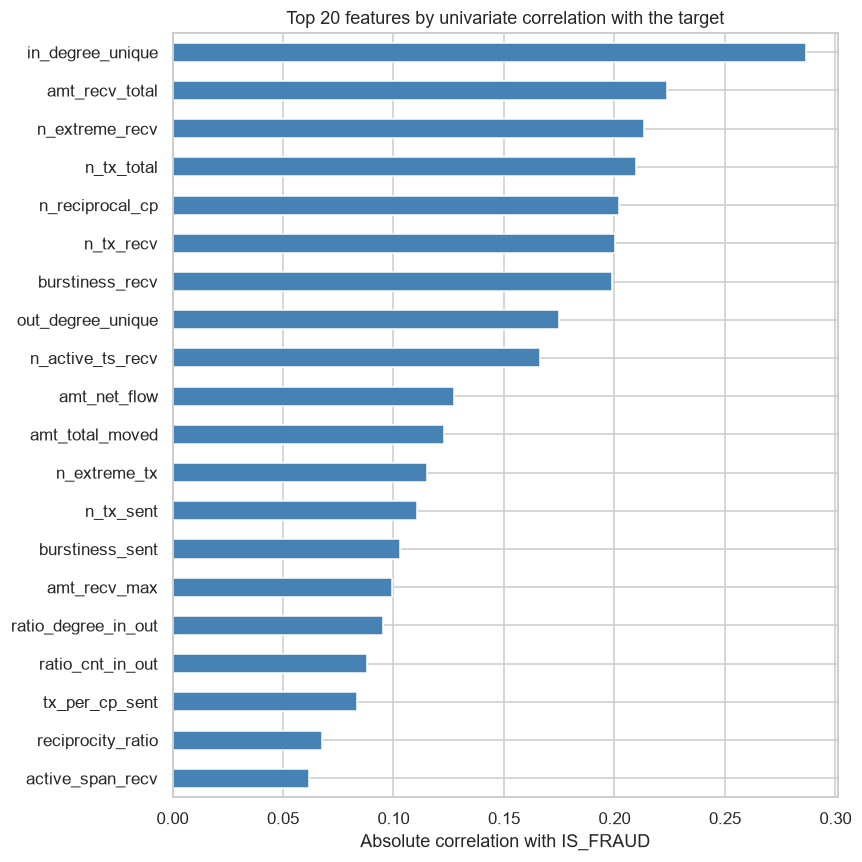

in_degree_unique     0.2868
amt_recv_total       0.2236
n_extreme_recv       0.2134
n_tx_total           0.2096
n_reciprocal_cp      0.2019
n_tx_recv            0.2003
burstiness_recv      0.1991
out_degree_unique    0.1749
n_active_ts_recv     0.1663
amt_net_flow         0.1275
amt_total_moved      0.1228
n_extreme_tx         0.1150
n_tx_sent            0.1108
burstiness_sent      0.1028
amt_recv_max         0.0995
dtype: float64


In [21]:
y = features["IS_FRAUD"].astype(int)
X_cols = [c for c in features.columns if c not in ["IS_FRAUD", "TX_BEHAVIOR_ID"]]

corr_target = features[X_cols].corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
corr_target.head(20).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Absolute correlation with IS_FRAUD")
ax.set_title("Top 20 features by univariate correlation with the target")
plt.tight_layout()
plt.show()

print(corr_target.head(15).round(4))

**Reading the results:**

**Theory confirmed.** The ranking is dominated by **inbound-flow** variables, consistent with `fan_in` concentrating its anomaly on the receiving account while the scheme's senders behave close to normally. `in_degree_unique` — distinct sending counterparties — leads the ranking, above the raw count of received transactions (`n_tx_recv`), validating the decision to distinguish between the two.

**Reciprocity contributes independent signal.** `n_reciprocal_cp` appears among the leading features. It is the feature designed specifically to capture `cycle` circularity, and its contribution is not reducible to volume.

**Burstiness contributes.** `burstiness_recv` ranks among the top features, supporting the hypothesis that scheme activity concentrates in bursts.

**`n_extreme_recv` requires caution.** It shows appreciable correlation, but as noted in Section 5.4, extreme transactions are distributed almost uniformly across classes. The correlation is likely mechanical rather than behavioral. It is retained for now and will be assessed with SHAP.

**No correlation exceeds ≈0.30.** This is consistent with the class overlap observed in the EDA boxplots and with the nature of the problem: AML signal resides in the **combination** of behaviors, not in any isolated indicator. This is precisely the regime in which a non-linear model (XGBoost) should outperform logistic regression — a hypothesis to be tested in the modeling notebook. It also establishes an expectation: a ROC-AUC near 0.99 would warrant suspicion of a leakage path rather than celebration.

## 8. Dataset export

Three artifacts are exported:

1. **`features_all.csv`** — the complete dataset with all features and the target.
2. **`train_ids.csv` / `test_ids.csv`** — the partition, ensuring the modeling notebook uses the identical split and results are reproducible.
3. **`feature_metadata.json`** — the winsorization threshold and configuration, for traceability.

In [22]:
import os, json

os.makedirs("data_processed", exist_ok=True)

features.to_csv("data_processed/features_all.csv")
pd.Series(sorted(train_ids), name="ACCOUNT_ID").to_csv("data_processed/train_ids.csv", index=False)
pd.Series(sorted(test_ids), name="ACCOUNT_ID").to_csv("data_processed/test_ids.csv", index=False)

metadata = {
    "amount_cap_p99_train_only": float(AMOUNT_CAP),
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "n_features": len(X_cols) + 1,  # + TX_BEHAVIOR_ID
    "target": "IS_FRAUD",
    "categorical_features": ["TX_BEHAVIOR_ID"],
    "excluded_for_leakage": ["ALERT_ID", "IS_FRAUD (transaction level)"],
    "excluded_zero_variance": ["COUNTRY", "ACCOUNT_TYPE"],
    "excluded_redundant": ["CUSTOMER_ID"],
}

with open("data_processed/feature_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Exported:")
print(f"  data_processed/features_all.csv       {features.shape}")
print(f"  data_processed/train_ids.csv          {len(train_ids)} accounts")
print(f"  data_processed/test_ids.csv           {len(test_ids)} accounts")
print(f"  data_processed/feature_metadata.json")
print()
print(json.dumps(metadata, indent=2))

Exported:
  data_processed/features_all.csv       (10000, 41)
  data_processed/train_ids.csv          7500 accounts
  data_processed/test_ids.csv           2500 accounts
  data_processed/feature_metadata.json

{
  "amount_cap_p99_train_only": 1826133.4604000056,
  "random_state": 42,
  "test_size": 0.25,
  "n_features": 40,
  "target": "IS_FRAUD",
  "categorical_features": [
    "TX_BEHAVIOR_ID"
  ],
  "excluded_for_leakage": [
    "ALERT_ID",
    "IS_FRAUD (transaction level)"
  ],
  "excluded_zero_variance": [
    "COUNTRY",
    "ACCOUNT_TYPE"
  ],
  "excluded_redundant": [
    "CUSTOMER_ID"
  ]
}


---

## Summary

**Features constructed:** 38 account-level features across seven families — volume, network degree, flow, counterparty repetition, reciprocity, temporal, and balance-relative.

**Design principle:** the typologies present are structural patterns, not volume anomalies. The feature set therefore prioritizes *with whom* and *how* an account transacts over *how much*. The clearest expression of this is the systematic distinction between transaction counts (`n_tx_*`) and distinct counterparties (`*_degree_unique`), whose separation proved to be the strongest signal in the set.

**Leakage prevention:**
- `ALERT_ID` and transaction-level `IS_FRAUD` excluded entirely.
- Train/test split executed **before** feature engineering.
- Winsorization threshold computed exclusively from training-set transactions and applied as a fixed constant.
- Scaling deferred to the modeling notebook, fitted on training folds only within a `Pipeline`.

**Principal finding:** inbound-flow and distinct-counterparty features carry the strongest univariate signal, consistent with the typologies present. Moderate magnitudes (maximum correlation ≈ 0.30) indicate that predictive capacity will depend on feature combinations rather than isolated indicators.

**Open question carried forward:** the contribution of `TX_BEHAVIOR_ID` will be quantified via SHAP and an ablation experiment, given its status as a generator-side parameter rather than an observation of behavior.

### Next stage

`03_modeling.ipynb` — training and comparison of Logistic Regression (baseline) and XGBoost, using `class_weight='balanced'` and `scale_pos_weight` respectively to address the 16.85% class imbalance; evaluation with PR-AUC, ROC-AUC, precision, recall and F1; and interpretation via SHAP.